In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
from pathlib import Path

# check if workding_dir is in local variables
if "workding_dir" not in locals():
    workding_dir = str(Path.cwd().parent)

os.chdir(workding_dir)
sys.path.append(workding_dir)
print("workding dir:", workding_dir)

workding dir: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge


In [3]:
from dotenv import find_dotenv, load_dotenv

found_dotenv = find_dotenv(".env")

if len(found_dotenv) == 0:
    found_dotenv = find_dotenv(".env.example")
print(f"loading env vars from: {found_dotenv}")
load_dotenv(found_dotenv, override=True)

loading env vars from: /Users/inflaton/code/engd/papers/multi-agent-llm-at-edge/.env


True

In [5]:
from src.misc.metrics import *

result_folder = "results/Anthropic/claude-3-7-sonnet-20250219-claude-3-7-sonnet-20250219"

db_filepath = f"{result_folder}/emails.db"
metrics = calculate_metrics(db_filepath)
df = metrics["df"]
del metrics["df"]
metrics

{'task_completion_rate': 1,
 'task_success_rate': 0.9929292929292929,
 'total_execution_time': 33212.686409,
 'mean_execution_time': 16.774084044949497,
 'std_execution_time': 12.271805209501931,
 'mean_process_steps': 8.547474747474748,
 'std_process_steps': 0.728589413504014,
 'total_tasks': 1980,
 'SUCCESS': 1966,
 'DB_UPDATE_TOOL_NOT_INITIALIZED': 6,
 'OCR_TOOL_RESULT_MISMATCH': 4,
 'OCR_TOOL_ERROR': 2,
 'DB_QUERY_TOOL_NOT_INITIALIZED': 1,
 'OCR_TOOL_NOT_INITIALIZED': 1}

In [6]:
df.head(5)

,email_id,sender_email,recipient_email,subject,email_body,attachments,process_status,response,start_time,end_time,...,total_time,successful_requests,total_tokens,prompt_tokens,completion_tokens,total_cost,original_process_status,process_steps,duration,duration_hms
0,93185A89130149C0A842968E4AFDCAA2,RobinLevine@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 43925,Hi Tanya ! Please find attached payment screen...,transaction_1.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-09 09:35:46.959489,2025-04-09 09:36:11.664770,...,24.7053,6,3698,3054,644,0.0,SUCCESS,9,24.705281,0 days 00:00:24
1,614972488B7B411BAEA4814CF066CDAA,StevenNixon@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 51782,Hi Tanya ! Please find attached payment screen...,transaction_2.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-09 09:36:11.670702,2025-04-09 09:36:29.394629,...,17.7239,6,3748,3147,601,0.0,SUCCESS,9,17.723927,0 days 00:00:17
2,C484ABEB38F44D29960B1CEF58510627,MadisonFord@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 42968,Hi Tanya ! Please find attached payment screen...,transaction_3.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-09 09:36:29.400221,2025-04-09 09:36:46.500174,...,17.1000,6,3722,3131,591,0.0,SUCCESS,9,17.099953,0 days 00:00:17
3,706B3403E8024178948B3BFBF9E64A25,KathrynJones@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 92948,Hi Tanya ! Please find attached payment screen...,transaction_4.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-09 09:36:46.504555,2025-04-09 09:37:02.446868,...,15.9423,6,3794,3142,652,0.0,SUCCESS,9,15.942313,0 days 00:00:15
4,86838440CA6C472AACFA3FCE1382609C,ChristineOwens@example.com,tanya.official.456@gmail.com,Payment Confirmation for Invoice ID: 20304,Hi Tanya ! Please find attached payment screen...,transaction_5.jpeg,SUCCESS,"{""content"": ""DONE""}",2025-04-09 09:37:02.452137,2025-04-09 09:37:19.270784,...,16.8186,6,3720,3078,642,0.0,SUCCESS,9,16.818647,0 days 00:00:16


In [7]:
import matplotlib.pyplot as plt


def plot_value_distribution(df_filtered, col="category", top_n=10):
    df_filtered[col].value_counts()[:top_n].plot(kind="bar")
    plt.title(f"Distribution of {col}")

    # add the count on top of the bars
    for i in range(len(df_filtered[col].value_counts()[:top_n])):
        count = df_filtered[col].value_counts().values[i]
        plt.text(i, count, count, ha="center")

    plt.show()

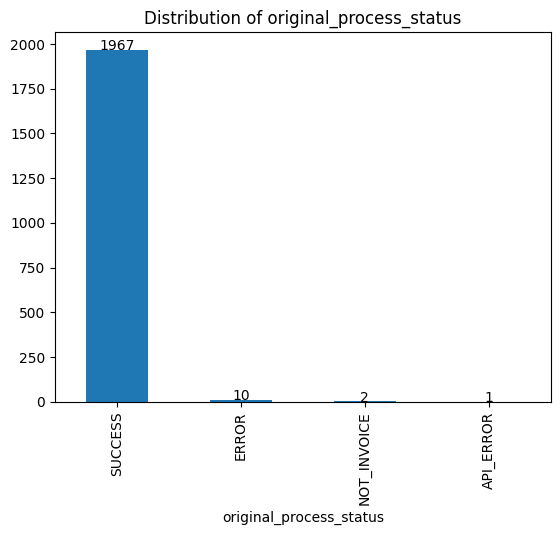

In [8]:
plot_value_distribution(df, "original_process_status")

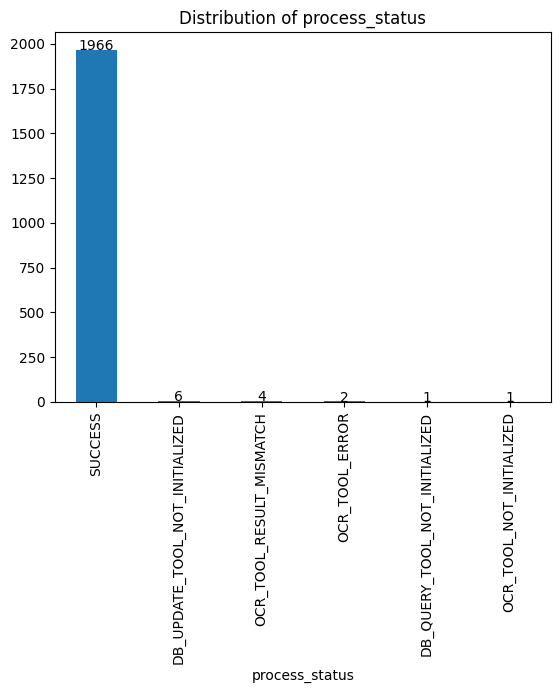

In [9]:
plot_value_distribution(df, "process_status")

In [10]:
print_row_details(df, [0])

--------------------------------------------------
email_id: 93185A89130149C0A842968E4AFDCAA2
--------------------------------------------------
sender_email: RobinLevine@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 43925
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine
--------------------------------------------------
attachments: transaction_1.jpeg
--------------------------------------------------
process_status: SUCCESS
--------------------------------------------------
response: {"content": "DONE"}
--------------------------------------------------
start_time: 2025-04-09 09:35:46.959489
--------------------------------------------------
end_time: 2025-04-09 09:36:11.664770
-----------------------------------------

In [11]:
import json

logs = json.loads(df.iloc[0]["full_logs"])
len(logs)

9

In [12]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: RobinLevine@example.com\n            Subject: Payment Confirmation for Invoice ID: 43925\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 43925 , Regards Robin Levine\n            Attachment: transaction_1.jpeg\n            \n                ",
    "timestamp": "2025-04-09T09:35:46.959489",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-09T09:35:49.745597",


In [13]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"Bank 538\\n\\nSent by: Robin Levine\\n\\n[Green checkmark icon]\\n\\nYou paid $196\\nto Tanya\\n\\nTransaction Reference Number:\\nEC4F9FE854344D25\\n\\nTransaction Date: 04/23/23\\n\\nInvoice ID: 43925\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 366, \"prompt_tokens\": 301, \"completion_tokens\": 65, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-09T09:35:49.745597",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"43925\", \"bank_name\": \"Bank 538\", \"transaction_id\": \"EC

3

In [14]:
df["process_status"].value_counts()

process_status
SUCCESS                           1966
DB_UPDATE_TOOL_NOT_INITIALIZED       6
OCR_TOOL_RESULT_MISMATCH             4
OCR_TOOL_ERROR                       2
DB_QUERY_TOOL_NOT_INITIALIZED        1
OCR_TOOL_NOT_INITIALIZED             1
Name: count, dtype: int64

In [15]:
df_filtered = (
    df[df["process_status"] == "DB_UPDATE_TOOL_NOT_INITIALIZED"].copy().reset_index(drop=True)
)
len(df_filtered)

6

In [16]:
print_row_details(df_filtered, [0])

--------------------------------------------------
email_id: A19D8753517049B1A870CEAD80AFE910
--------------------------------------------------
sender_email: BrittanyMcguire@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 67756
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 67756 , Regards Brittany Mcguire
--------------------------------------------------
attachments: transaction_211.jpeg
--------------------------------------------------
process_status: DB_UPDATE_TOOL_NOT_INITIALIZED
--------------------------------------------------
response: I'll reconcile this invoice based on the provided information.

Looking at both the email/OCR data and the database query result:

Email/OCR data shows:
- Invoice ID: 67756
- Amount: $14
- Sender: Brittany 

In [17]:
import json

logs = json.loads(df_filtered.iloc[0]["full_logs"])
len(logs)

7

In [18]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: BrittanyMcguire@example.com\n            Subject: Payment Confirmation for Invoice ID: 67756\n            Body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 67756 , Regards Brittany Mcguire\n            Attachment: transaction_211.jpeg\n            \n                ",
    "timestamp": "2025-04-09T10:43:38.207547",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "finance_clerk",
    "type": "AIMessage",
    "content": "Tool calls to ocr_tool",
    "timestamp": "2025-04-09T10:43:42

In [19]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "ocr_tool",
    "type": "ToolMessage",
    "content": "{\"content\": \"Bank 341\\n\\nSent by: Brittany Mcguire\\n\\n[Checkmark symbol in a circle]\\n\\nYou paid $14\\nto Tanya\\n\\nTransaction Reference Number:\\n11646ECDDBC496A\\n\\nTransaction Date: 09/10/24\\n\\nInvoice ID: 67756\", \"usage\": {\"successful_requests\": 1, \"total_tokens\": 370, \"prompt_tokens\": 301, \"completion_tokens\": 69, \"total_cost\": 0.0}}",
    "timestamp": "2025-04-09T10:43:42.637166",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}
{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"67756\", \"bank_name\": \"Bank 341\", \"transaction_

2

In [20]:
logs[-1]

{'name': 'senior_reconciliation_agent',
 'type': 'AIMessage',
 'content': 'I\'ll reconcile this invoice based on the provided information.\n\nLooking at both the email/OCR data and the database query result:\n\nEmail/OCR data shows:\n- Invoice ID: 67756\n- Amount: $14\n- Sender: Brittany Mcguire\n- Recipient: Tanya\n- Transaction Reference: 11646ECDDBC496A\n- Bank: Bank 341\n\nDatabase shows:\n- Invoice ID: 67756\n- Amount: $14.00\n- Sender: Brittany Mcguire\n- Recipient: Tanya\n- Transaction ID: 11646ECDDB0C496A\n- Bank: Bank 341\n\nThere\'s a slight discrepancy in the transaction reference/ID. The OCR shows "11646ECDDBC496A" while the database has "11646ECDDB0C496A" (missing a "B").\n\nERROR The transaction reference number doesn\'t match between the OCR data and database. OCR shows "11646ECDDBC496A" while database has "11646ECDDB0C496A".',
 'timestamp': '2025-04-09T10:43:54.425812',
 'usage': {'input_tokens': 606,
  'output_tokens': 253,
  'total_tokens': 859,
  'input_token_details

In [32]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = 67756"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1

In [33]:
print_row_details(df_txn)

--------------------------------------------------
invoice_id: 67756
--------------------------------------------------
bank_name: Bank 341
--------------------------------------------------
transaction_id: 11646ECDDB0C496A
--------------------------------------------------
amount: 14.0
--------------------------------------------------
recipient_name: Tanya
--------------------------------------------------
sender_name: Brittany Mcguire
--------------------------------------------------
reconciliation_state: UNPAID
--------------------------------------------------
email_details: 


In [23]:
print_row_details(df_filtered, [-1])

--------------------------------------------------
email_id: E-614972488B7B411BAEA4814CF066CDAA
--------------------------------------------------
sender_email: StevenNixon@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 1051782
--------------------------------------------------
email_body: Dear Tanya, I hope this message finds you well.I am writing to confirm that we have successfully made the payment for Invoice ID: 1051782, related to our recent order with you. Here are the details:  
Invoice ID: 1051782
Invoice Date: 6/5/24
Total Amount paid: 159.0
Transaction Reference Number - T-3D2ADBBC17B641C4
Thank you and I look forward to our continued business
Best regards,
Steven Nixon
--------------------------------------------------
attachments: 
--------------------------------------------------
process_status: DB_UPDATE_TOOL_NOT_

In [24]:
import json

logs = json.loads(df_filtered.iloc[-1]["full_logs"])
len(logs)

8

In [25]:
for log in logs:
    # pretty print the log json
    print(json.dumps(log, indent=4))
    print("===" * 20)

{
    "name": "input",
    "type": "HumanMessage",
    "content": "\n                Help to reconcile invoices using the following email:\n\n                \n            Sender: StevenNixon@example.com\n            Subject: Payment Confirmation for Invoice ID: 1051782\n            Body: Dear Tanya, I hope this message finds you well.I am writing to confirm that we have successfully made the payment for Invoice ID: 1051782, related to our recent order with you. Here are the details:  \nInvoice ID: 1051782\nInvoice Date: 6/5/24\nTotal Amount paid: 159.0\nTransaction Reference Number - T-3D2ADBBC17B641C4\nThank you and I look forward to our continued business\nBest regards,\nSteven Nixon\n            \n            \n                ",
    "timestamp": "2025-04-09T14:35:34.185109",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_

In [26]:
tool_call_logs = []
for log in logs:
    if log["name"] in ["ocr_tool", "invoice_db_query_tool", "invoice_db_update_tool"]:
        # pretty print the log json
        print(json.dumps(log, indent=4))
        print("===" * 20)
        tool_call_logs.append(log)
len(tool_call_logs)

{
    "name": "invoice_db_query_tool",
    "type": "ToolMessage",
    "content": "{\"content\": {\"invoice_id\": \"1051782\", \"bank_name\": \"Bank 533\", \"transaction_id\": \"T-3D2ADBBC17B641C4\", \"amount\": \"$159.00\", \"recipient_name\": \"Tanya\", \"sender_name\": \"Steven Nixon\"}}",
    "timestamp": "2025-04-09T14:35:52.019764",
    "usage": {
        "input_tokens": 0,
        "output_tokens": 0,
        "total_tokens": 0,
        "input_token_details": {
            "audio": 0,
            "cache_read": 0
        },
        "output_token_details": {
            "audio": 0,
            "reasoning": 0
        }
    },
    "model_name": "",
    "additional_kwargs": {}
}


1

In [27]:
logs[-1]

{'name': 'senior_reconciliation_agent',
 'type': 'AIMessage',
 'content': 'I need to clarify the situation based on the information provided.\n\nERROR The update format is incorrect. The email details should be provided in a structured format that includes the sender, subject, and body of the email for proper documentation in our reconciliation system. Please reformat the update request with the complete email information from the original message.',
 'timestamp': '2025-04-09T14:36:03.535606',
 'usage': {'input_tokens': 1106,
  'output_tokens': 71,
  'total_tokens': 1177,
  'input_token_details': {},
  'output_token_details': {}},
 'model_name': 'claude-3-7-sonnet-20250219',
 'additional_kwargs': {}}

In [28]:
from src.misc.metrics import *

db_filepath = f"{result_folder}/transactions.db"
query = "SELECT * FROM transactions WHERE invoice_id = 1095432"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

1

In [29]:
print_row_details(df_txn)

--------------------------------------------------
invoice_id: 1095432
--------------------------------------------------
bank_name: Bank 815
--------------------------------------------------
transaction_id: T-7993615CB2C34EE5
--------------------------------------------------
amount: 167.0
--------------------------------------------------
recipient_name: Tanya
--------------------------------------------------
sender_name: Kelly Miller
--------------------------------------------------
reconciliation_state: PAID
--------------------------------------------------
email_details: Invoice ID: 1095432
Invoice Date: 5/21/24
Total Amount: $167.00
Transaction Reference Number: T-7993615CB2C34EE5
Sender: Kelly Miller
Recipient: Tanya
Bank Name: Bank 815
Reconciliation Status: Completed - Amount Verified


In [30]:
query = "SELECT * FROM transactions WHERE reconciliation_state = 'UNPAID'"

df_txn = run_sql_query(db_filepath, query)

len(df_txn)

13

In [31]:
print_row_details(df_filtered, range(len(df_filtered)), ["response"])

--------------------------------------------------
response: I'll reconcile this invoice based on the provided information.

Looking at both the email/OCR data and the database query result:

Email/OCR data shows:
- Invoice ID: 67756
- Amount: $14
- Sender: Brittany Mcguire
- Recipient: Tanya
- Transaction Reference: 11646ECDDBC496A
- Bank: Bank 341

Database shows:
- Invoice ID: 67756
- Amount: $14.00
- Sender: Brittany Mcguire
- Recipient: Tanya
- Transaction ID: 11646ECDDB0C496A
- Bank: Bank 341

There's a slight discrepancy in the transaction reference/ID. The OCR shows "11646ECDDBC496A" while the database has "11646ECDDB0C496A" (missing a "B").

ERROR The transaction reference number doesn't match between the OCR data and database. OCR shows "11646ECDDBC496A" while database has "11646ECDDB0C496A".
--------------------------------------------------
response: I need to check if the invoice data from the email and OCR matches our database records.

Comparing the information:
- Invoic

In [34]:
df_filtered = (
    df[df["process_status"] == "OCR_TOOL_NOT_INITIALIZED"].copy().reset_index(drop=True)
)
len(df_filtered)

1

In [37]:
print_row_details(df_filtered, range(len(df_filtered)))

--------------------------------------------------
email_id: 254C3A2C88B54960839969DD08BF0932
--------------------------------------------------
sender_email: JuanBarr@example.com
--------------------------------------------------
recipient_email: tanya.official.456@gmail.com
--------------------------------------------------
subject: Payment Confirmation for Invoice ID: 94876
--------------------------------------------------
email_body: Hi Tanya ! Please find attached payment screenshot for Invoice ID: 94876 , Regards Juan Barr
--------------------------------------------------
attachments: transaction_975.jpeg
--------------------------------------------------
process_status: OCR_TOOL_NOT_INITIALIZED
--------------------------------------------------
response: EXCEPTION: Error code: 529 - {'error': {'code': 'overloaded_error', 'message': 'Overloaded', 'type': 'invalid_request_error', 'param': None}}
--------------------------------------------------
start_time: 2025-04-09 14:21:06.2